# OECD Main Economic Indicators — Interactive Dashboard

**Verified dataflows** (as of 2026-02) via OECD SDMX REST catalogue:

| Block | Dataflow | Measures |
|---|---|---|
| B · Leading | `DSD_STES@DF_CLI 4.1` | LI · BCICP · CCICP |
| C · Production | `DSD_KEI@DF_KEI 4.0` | PRVM · CP |
| D · Labour | `DSD_KEI@DF_KEI 4.0` | UNEMP |
| E · Financial | KEI + `DSD_STES@DF_FINMARK 4.0` | IR3TIB · IRLT · SHARE |

> **Run:** `Cell → Run All Cells`. First run ~2–3 min (live API); subsequent runs <10 s (24h cache).

In [1]:
# ── A1 · Imports & Configuration ─────────────────────────────────────────────
import io, time as _time, pickle, hashlib, warnings
from pathlib import Path
from datetime import datetime

import requests
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display

warnings.filterwarnings("ignore")

# ── API constants ──────────────────────────────────────────────────────────────
OECD_BASE     = "https://sdmx.oecd.org/public/rest/data"
START_TIME    = "2015"       # used as startPeriod
CACHE_TTL     = 86400        # 24 h
REQUEST_DELAY = 3.5          # seconds between live requests

# ── Dataflows (verified against OECD SDMX catalogue) ─────────────────────────
# DF_STLABOUR / DF_STPRI / DF_KEI(DSD_STES) do NOT exist — see README.
DATAFLOWS = {
    "CLI":     "OECD.SDD.STES,DSD_STES@DF_CLI,4.1",      # Leading indicators
    "KEI":     "OECD.SDD.STES,DSD_KEI@DF_KEI,4.0",       # Key economic indicators
    "FINMARK": "OECD.SDD.STES,DSD_STES@DF_FINMARK,4.0",  # Financial markets
}

# ── Subject codes (verified from csvfilewithlabels responses) ─────────────────
SUBJECT_CODES = {
    "CLI":        "LI",       # Composite Leading Indicator
    "BCI":        "BCICP",    # Business Confidence (amplitude-adjusted index)
    "CCI":        "CCICP",    # Consumer Confidence (amplitude-adjusted index)
    "IPI":        "PRVM",     # Manufacturing Production Volume (KEI, SA level)
    "CPI":        "CP",       # Consumer Prices YoY% (KEI, pre-computed)
    "UNEMP":      "UNEMP",    # Unemployment rate (KEI, SA)
    "RATE_SHORT": "IR3TIB",   # 3-month interbank rate
    "RATE_LONG":  "IRLT",     # Long-term government bond yield
    "EQUITY":     "SHARE",    # Share price index (FINMARK)
}

# ── Country universe ───────────────────────────────────────────────────────────
# G7M aggregate not present in KEI/CLI — using OECD + EA19 as aggregates
COUNTRY_LIST = [
    "USA", "GBR", "DEU", "FRA", "ITA", "CAN", "JPN",          # G7
    "AUS", "AUT", "BEL", "CHE", "DNK", "ESP", "FIN",          # Other OECD
    "GRC", "HUN", "IRL", "KOR", "MEX", "NLD", "NOR",
    "NZL", "POL", "PRT", "SWE", "TUR",
    "OECD", "EA19",                                             # Aggregates
]

COUNTRY_LABELS = {
    "USA": "United States", "GBR": "United Kingdom", "DEU": "Germany",
    "FRA": "France",        "ITA": "Italy",           "CAN": "Canada",
    "JPN": "Japan",         "AUS": "Australia",       "AUT": "Austria",
    "BEL": "Belgium",       "CHE": "Switzerland",     "DNK": "Denmark",
    "ESP": "Spain",         "FIN": "Finland",         "GRC": "Greece",
    "HUN": "Hungary",       "IRL": "Ireland",         "KOR": "Korea",
    "MEX": "Mexico",        "NLD": "Netherlands",     "NOR": "Norway",
    "NZL": "New Zealand",   "POL": "Poland",          "PRT": "Portugal",
    "SWE": "Sweden",        "TUR": "Turkey",
    "OECD": "OECD Total",   "EA19": "Euro Area (19)",
}

COUNTRY_COLORS = {
    "USA": "#1f77b4", "GBR": "#d62728", "DEU": "#2ca02c", "FRA": "#9467bd",
    "ITA": "#8c564b", "CAN": "#e377c2", "JPN": "#bcbd22", "AUS": "#17becf",
    "AUT": "#aec7e8", "BEL": "#ffbb78", "CHE": "#98df8a", "DNK": "#ff9896",
    "ESP": "#c5b0d5", "FIN": "#c49c94", "GRC": "#f7b6d2", "HUN": "#c7c7c7",
    "IRL": "#dbdb8d", "KOR": "#9edae5", "MEX": "#393b79", "NLD": "#637939",
    "NOR": "#8c6d31", "NZL": "#843c39", "POL": "#7b4173", "PRT": "#a55194",
    "SWE": "#ce6dbd", "TUR": "#de9ed6",
    "OECD": "#000000", "EA19": "#444444",
}

G7         = ["USA", "GBR", "DEU", "FRA", "ITA", "CAN", "JPN"]
AGGREGATES = ["OECD", "EA19"]

print("✅ A1 · Configuration loaded")
print(f"   Countries: {len(COUNTRY_LIST)}  |  Start: {START_TIME}  |  Cache TTL: {CACHE_TTL//3600}h")


✅ A1 · Configuration loaded
   Countries: 28  |  Start: 2015  |  Cache TTL: 24h


In [2]:
# ── A2 · File Cache ───────────────────────────────────────────────────────────
CACHE_DIR = Path("./oecd_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def _cache_key(url: str) -> str:
    return hashlib.md5(url.encode()).hexdigest()

def cache_get(url: str):
    path = CACHE_DIR / f"{_cache_key(url)}.pkl"
    if not path.exists():
        return None
    try:
        with open(path, "rb") as f:
            entry = pickle.load(f)
        if _time.time() - entry["ts"] > CACHE_TTL:
            path.unlink(missing_ok=True)
            return None
        return entry["text"]
    except Exception:
        return None

def cache_set(url: str, text: str) -> None:
    path = CACHE_DIR / f"{_cache_key(url)}.pkl"
    with open(path, "wb") as f:
        pickle.dump({"ts": _time.time(), "text": text}, f)

print(f"✅ A2 · Cache ready  →  {CACHE_DIR.resolve()}")


✅ A2 · Cache ready  →  /Users/macproajb/boquin.github.io/reports/oecd-mei/oecd_cache


In [3]:
# ── A3 · OECD SDMX API Client ────────────────────────────────────────────────
# DSD dimension order (9 dims): REF_AREA · FREQ · MEASURE · UNIT_MEASURE ·
#   ACTIVITY · ADJUSTMENT · TRANSFORMATION · TIME_HORIZ · METHODOLOGY
# Key format: {countries}.{freq}.{subjects}......   (6 trailing wildcards)
# Query param: startPeriod (NOT startTime)

_last_req_t = 0.0

def _build_key(countries, subjects, freq="M"):
    """Build SDMX series key with 9 dimensions (6 wildcards for dims 4-9)."""
    c = "+".join(countries) if isinstance(countries, (list, tuple)) else countries
    s = "+".join(subjects)  if isinstance(subjects,  (list, tuple)) else subjects
    return f"{c}.{freq}.{s}......"   # 8 dots total → 9 dimension slots

def fetch_oecd(dataflow: str, countries, subjects,
               start_time: str = START_TIME, freq: str = "M") -> str:
    """Fetch OECD SDMX data with cache + rate-limit + retry."""
    global _last_req_t
    series_key = _build_key(countries, subjects, freq)
    url = (f"{OECD_BASE}/{dataflow}/{series_key}"
           f"?startPeriod={start_time}&format=csvfilewithlabels")

    cached = cache_get(url)
    if cached is not None:
        print(f"  💾  cache hit  ·  {dataflow.split('@')[-1].split(',')[0]}  /  {series_key[:55]}…")
        return cached

    elapsed = _time.time() - _last_req_t
    if elapsed < REQUEST_DELAY:
        _time.sleep(REQUEST_DELAY - elapsed)

    for attempt in range(3):
        try:
            resp = requests.get(url, timeout=90,
                                headers={"Accept": "text/csv, application/csv"})
            _last_req_t = _time.time()
            if resp.status_code == 429:
                wait = int(resp.headers.get("Retry-After", 60))
                print(f"  ⏳  rate-limited — waiting {wait}s …")
                _time.sleep(wait)
                continue
            resp.raise_for_status()
            text = resp.text
            cache_set(url, text)
            df_name = dataflow.split("@")[-1].split(",")[0]
            print(f"  ✅  fetched  ·  {df_name}  /  {series_key[:55]}…")
            return text
        except requests.exceptions.RequestException as e:
            if attempt == 2:
                print(f"  ❌  failed after 3 attempts: {e}")
                return ""
            print(f"  ⚠️   attempt {attempt+1}: {e}  — retrying…")
            _time.sleep(5)
    return ""

def parse_sdmx_csv(raw_text: str) -> pd.DataFrame:
    """Parse SDMX csvfilewithlabels → MultiIndex(date, country, subject) DF.
    Also retains ADJUSTMENT and TRANSFORMATION as columns for downstream filtering."""
    if not raw_text or len(raw_text.strip()) < 20:
        return pd.DataFrame()

    df = pd.read_csv(io.StringIO(raw_text), low_memory=False)
    col_map = {}
    for col in df.columns:
        cu = col.upper()
        if cu == "REF_AREA" and "country" not in col_map:
            col_map["country"] = col
        elif cu == "MEASURE" and "subject" not in col_map:
            col_map["subject"] = col
        elif cu == "TIME_PERIOD" and "date" not in col_map:
            col_map["date"] = col
        elif cu == "OBS_VALUE" and "value" not in col_map:
            col_map["value"] = col
        elif cu == "ADJUSTMENT" and "adjustment" not in col_map:
            col_map["adjustment"] = col
        elif cu == "TRANSFORMATION" and "transformation" not in col_map:
            col_map["transformation"] = col

    missing = [k for k in ("country", "subject", "date", "value") if k not in col_map]
    if missing:
        print(f"  ⚠️   parse_sdmx_csv: missing {missing}. Cols: {list(df.columns[:8])}")
        return pd.DataFrame()

    out = pd.DataFrame({
        "country":        df[col_map["country"]].astype(str),
        "subject":        df[col_map["subject"]].astype(str),
        "date":           pd.to_datetime(df[col_map["date"]], format="%Y-%m", errors="coerce"),
        "value":          pd.to_numeric(
                              df[col_map["value"]].replace({" ": np.nan, "..": np.nan}),
                              errors="coerce"),
        "adjustment":     df[col_map["adjustment"]].astype(str) if "adjustment" in col_map else "_Z",
        "transformation": df[col_map["transformation"]].astype(str) if "transformation" in col_map else "_Z",
    }).dropna(subset=["date"])

    return out.set_index(["date", "country", "subject"]).sort_index()

def pivot_wide(df: pd.DataFrame,
               subject_filter=None,
               country_filter=None,
               adjustment: str = None,
               transformation: str = None) -> pd.DataFrame:
    """Pivot to wide (date × country). Optionally filter by adjustment/transformation."""
    if df.empty:
        return pd.DataFrame()
    r = df.reset_index()
    if subject_filter:
        sf = [subject_filter] if isinstance(subject_filter, str) else list(subject_filter)
        r = r[r["subject"].isin(sf)]
    if country_filter:
        cf = [country_filter] if isinstance(country_filter, str) else list(country_filter)
        r = r[r["country"].isin(cf)]
    # Prefer seasonally-adjusted level if multiple variants present
    if adjustment and "adjustment" in r.columns:
        adj_rows = r[r["adjustment"] == adjustment]
        if not adj_rows.empty:
            r = adj_rows
    if transformation and "transformation" in r.columns:
        tr_rows = r[r["transformation"] == transformation]
        if not tr_rows.empty:
            r = tr_rows
    if r.empty:
        return pd.DataFrame()
    pivot = r.pivot_table(index="date", columns="country", values="value", aggfunc="last")
    return pivot.sort_index()

def test_connection():
    """Fetch 2 months of USA CLI to verify API format."""
    print("Testing connectivity (USA CLI, 2024-11→2024-12) …")
    series_key = _build_key(["USA"], ["LI"])
    url = (f"{OECD_BASE}/{DATAFLOWS['CLI']}/{series_key}"
           f"?startPeriod=2024-11&endPeriod=2024-12&format=csvfilewithlabels")
    resp = requests.get(url, timeout=30)
    print(f"  HTTP {resp.status_code}")
    if resp.ok:
        df = parse_sdmx_csv(resp.text)
        print(df.reset_index()[["date","country","subject","value"]].to_string(index=False))

# Uncomment to verify before running all:
# test_connection()
print("✅ A3 · API client ready  (startPeriod · 9-dim key · correct dataflows)")


✅ A3 · API client ready  (startPeriod · 9-dim key · correct dataflows)


---
## Block B · Leading Indicators

In [4]:
# ── B1 · Fetch Leading Indicators ────────────────────────────────────────────
# Dataflow: DF_CLI 4.1  |  Measures: LI (CLI), BCICP (BCI), CCICP (CCI)
print("Fetching Leading Indicators (DF_CLI) …")

_b_subjects = [SUBJECT_CODES["CLI"], SUBJECT_CODES["BCI"], SUBJECT_CODES["CCI"]]
_raw_cli    = fetch_oecd(DATAFLOWS["CLI"], COUNTRY_LIST, _b_subjects)
_df_cli     = parse_sdmx_csv(_raw_cli)

print(f"\n📊  CLI raw: {_df_cli.shape}")
if not _df_cli.empty:
    r = _df_cli.reset_index()
    print("  Countries:", sorted(r["country"].unique().tolist()))
    print("  Subjects: ", sorted(r["subject"].unique().tolist()))


Fetching Leading Indicators (DF_CLI) …
  ✅  fetched  ·  DF_CLI  /  USA+GBR+DEU+FRA+ITA+CAN+JPN+AUS+AUT+BEL+CHE+DNK+ESP+FIN…

📊  CLI raw: (13434, 3)
  Countries: ['AUS', 'AUT', 'BEL', 'CAN', 'CHE', 'DEU', 'DNK', 'EA19', 'ESP', 'FIN', 'FRA', 'GBR', 'GRC', 'HUN', 'IRL', 'ITA', 'JPN', 'KOR', 'MEX', 'NLD', 'NOR', 'NZL', 'OECD', 'POL', 'PRT', 'SWE', 'TUR', 'USA']
  Subjects:  ['BCICP', 'CCICP', 'LI']


In [5]:
# ── B2 · Parse Leading Indicators ────────────────────────────────────────────
def smooth3m(df):
    return df.rolling(3, center=True, min_periods=2).mean()

# CLI uses amplitude-adjusted (AA) index; BCI/CCI same
cli_wide = pivot_wide(_df_cli, subject_filter=SUBJECT_CODES["CLI"],  adjustment="AA", transformation="IX")
bci_wide = pivot_wide(_df_cli, subject_filter=SUBJECT_CODES["BCI"], adjustment="AA", transformation="IX")
cci_wide = pivot_wide(_df_cli, subject_filter=SUBJECT_CODES["CCI"], adjustment="AA", transformation="IX")

# Fall back to any variant if AA/IX not available for a country
if cli_wide.empty:
    cli_wide = pivot_wide(_df_cli, subject_filter=SUBJECT_CODES["CLI"])
if bci_wide.empty:
    bci_wide = pivot_wide(_df_cli, subject_filter=SUBJECT_CODES["BCI"])
if cci_wide.empty:
    cci_wide = pivot_wide(_df_cli, subject_filter=SUBJECT_CODES["CCI"])

cli_smooth = smooth3m(cli_wide)
bci_smooth = smooth3m(bci_wide)
cci_smooth = smooth3m(cci_wide)

print(f"✅  CLI: {cli_wide.shape}  |  BCI: {bci_wide.shape}  |  CCI: {cci_wide.shape}")
if not cli_wide.empty:
    display(cli_wide.dropna(how="all").tail(3).round(2))


✅  CLI: (133, 12)  |  BCI: (133, 28)  |  CCI: (133, 26)


country,AUS,CAN,DEU,ESP,FRA,GBR,ITA,JPN,KOR,MEX,TUR,USA
date,,,,,,,,,,,,
2025-11-01,100.63,101.31,101.13,101.09,101.02,101.03,101.24,100.32,101.45,101.57,100.27,100.29
2025-12-01,100.70,101.59,101.26,101.51,101.28,101.04,101.50,100.41,101.69,101.83,100.58,100.42
2026-01-01,100.77,101.87,101.40,101.92,101.53,101.07,101.74,100.50,101.91,102.13,100.83,100.55


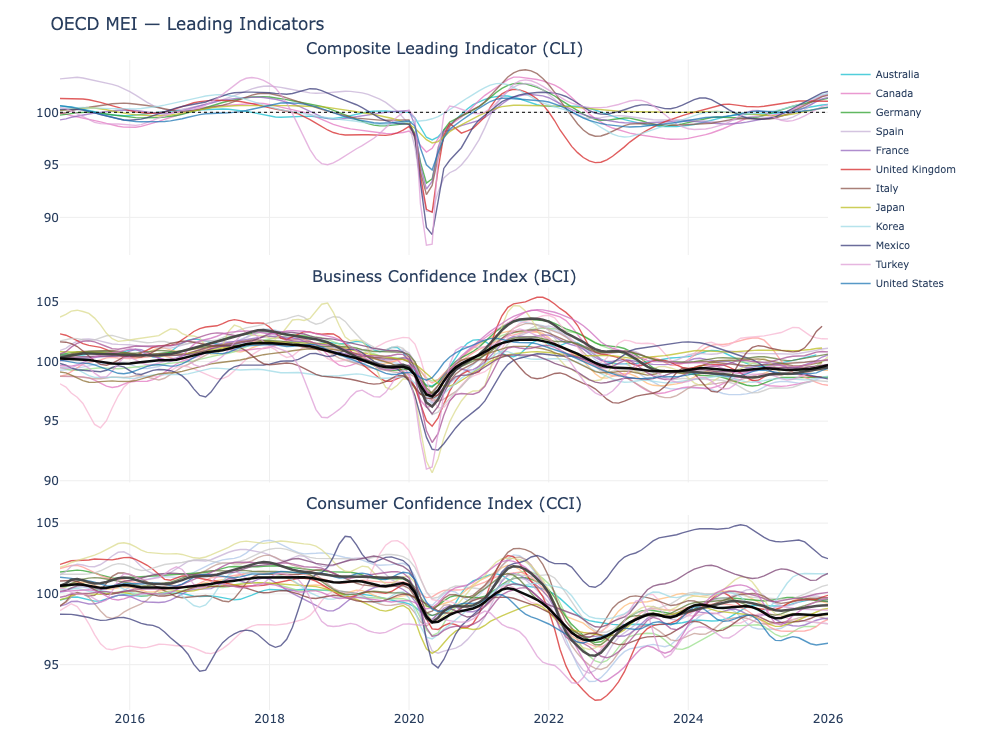

✅ B3 · Leading Indicators chart rendered


In [6]:
# ── B3 · Chart — Leading Indicators ──────────────────────────────────────────
def _line_kw(country):
    is_agg = country in AGGREGATES
    return dict(
        line=dict(color=COUNTRY_COLORS.get(country, "#aaaaaa"),
                  width=2.5 if is_agg else 1.4),
        opacity=0.95 if is_agg else 0.75,
    )

leading_fig = make_subplots(
    rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.05,
    subplot_titles=["Composite Leading Indicator (CLI)",
                    "Business Confidence Index (BCI)",
                    "Consumer Confidence Index (CCI)"],
)

for row, (df_w, label) in enumerate([
        (cli_smooth if not cli_smooth.empty else cli_wide, "CLI"),
        (bci_smooth if not bci_smooth.empty else bci_wide, "BCI"),
        (cci_smooth if not cci_smooth.empty else cci_wide, "CCI")], start=1):
    if df_w.empty:
        continue
    cols_sorted = sorted(df_w.columns, key=lambda c: (c in AGGREGATES, c))
    for country in cols_sorted:
        s = df_w[country].dropna()
        if s.empty:
            continue
        name = COUNTRY_LABELS.get(country, country)
        leading_fig.add_trace(
            go.Scatter(x=s.index, y=s.values, name=name,
                       legendgroup=name, showlegend=(row == 1),
                       hovertemplate=f"<b>{name}</b><br>%{{x|%Y-%m}}: %{{y:.2f}}<extra></extra>",
                       **_line_kw(country)),
            row=row, col=1)
    if row == 1:
        leading_fig.add_hline(y=100, line_dash="dot", line_color="black",
                               line_width=1, row=row, col=1)

leading_fig.update_layout(
    title="OECD MEI — Leading Indicators", height=750,
    legend=dict(orientation="v", x=1.01, y=1, font=dict(size=10), tracegroupgap=0),
    hovermode="x unified", template="plotly_white",
    margin=dict(l=60, r=180, t=60, b=40))
leading_fig.update_xaxes(showgrid=True, gridcolor="#eeeeee")
leading_fig.update_yaxes(showgrid=True, gridcolor="#eeeeee")

leading_fig.show()
print("✅ B3 · Leading Indicators chart rendered")


---
## Block C · Industrial Production & Prices

In [7]:
# ── C1 · Fetch Industrial Production & Consumer Prices (KEI) ──────────────────
# Dataflow: DF_KEI 4.0  |  IPI=PRVM (SA level), CPI=CP (YoY%, pre-computed)
print("Fetching Industrial Production & Prices (DF_KEI) …")

_c_subjects = [SUBJECT_CODES["IPI"], SUBJECT_CODES["CPI"]]
_raw_kei_c  = fetch_oecd(DATAFLOWS["KEI"], COUNTRY_LIST, _c_subjects)
_df_kei_c   = parse_sdmx_csv(_raw_kei_c)

print(f"\n📊  KEI (production+prices) raw: {_df_kei_c.shape}")
if not _df_kei_c.empty:
    r = _df_kei_c.reset_index()
    print("  Subjects: ", sorted(r["subject"].unique().tolist()))
    print("  Countries:", sorted(r["country"].unique().tolist())[:10], "…")


Fetching Industrial Production & Prices (DF_KEI) …
  ✅  fetched  ·  DF_KEI  /  USA+GBR+DEU+FRA+ITA+CAN+JPN+AUS+AUT+BEL+CHE+DNK+ESP+FIN…

📊  KEI (production+prices) raw: (37920, 3)
  Subjects:  ['CP', 'PRVM']
  Countries: ['AUS', 'AUT', 'BEL', 'CAN', 'CHE', 'DEU', 'DNK', 'EA19', 'ESP', 'FIN'] …


In [8]:
# ── C2 · Parse Industrial Production & Prices ─────────────────────────────────
def yoy(df):
    return df.pct_change(12).mul(100).replace([np.inf, -np.inf], np.nan)

# IPI: SA level (adjustment=Y, transformation=_Z); compute YoY ourselves
ipi_wide = pivot_wide(_df_kei_c, subject_filter=SUBJECT_CODES["IPI"],
                      adjustment="Y", transformation="_Z")
ipi_wide.ffill(limit=3, inplace=True)
ipi_yoy  = yoy(ipi_wide)

# CPI: already YoY% (transformation=GY in KEI)
cpi_wide = pivot_wide(_df_kei_c, subject_filter=SUBJECT_CODES["CPI"],
                      transformation="GY")
cpi_wide.ffill(limit=3, inplace=True)

print(f"✅  IPI level: {ipi_wide.shape}  |  IPI YoY: {ipi_yoy.shape}")
print(f"   CPI YoY:   {cpi_wide.shape}")
if not ipi_yoy.empty:
    print("\nLatest IPI YoY%:")
    display(ipi_yoy.dropna(how="all").tail(2).round(2))


✅  IPI level: (132, 27)  |  IPI YoY: (132, 27)
   CPI YoY:   (133, 26)

Latest IPI YoY%:


country,AUS,AUT,BEL,CAN,CHE,DEU,DNK,EA19,ESP,FIN,...,KOR,MEX,NLD,NOR,OECD,POL,PRT,SWE,TUR,USA
date,,,,,,,,,,,,,,,,,,,,,
2025-11-01,1.86,-4.33,-2.54,-3.36,9.72,0.98,-0.55,0.0,-20.15,1.37,...,9.00,-5.29,-27.73,1.63,1.39,2.19,0.31,-0.96,2.71,-48.57
2025-12-01,1.86,-2.34,-1.88,-3.67,6.12,-0.66,-5.84,0.0,-21.95,2.09,...,12.96,-2.90,-0.56,3.69,1.10,6.42,-18.68,4.32,36.82,-47.99


In [9]:
# ── C3 · Chart — Industrial Production & Prices ───────────────────────────────
production_fig = make_subplots(
    rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.06,
    subplot_titles=["Manufacturing Production Index (SA, 2015 base)",
                    "Manufacturing Production — Year-on-Year %",
                    "Consumer Prices — Year-on-Year %"],
)

for row, (df_w, fmt) in enumerate([
        (ipi_wide,  "{y:.1f}"),
        (ipi_yoy,   "{y:.1f}%"),
        (cpi_wide,  "{y:.1f}%")], start=1):
    for country in (df_w.columns if not df_w.empty else []):
        s = df_w[country].dropna()
        if s.empty:
            continue
        name = COUNTRY_LABELS.get(country, country)
        production_fig.add_trace(
            go.Scatter(x=s.index, y=s.values, name=name,
                       legendgroup=name, showlegend=(row == 1),
                       hovertemplate=f"<b>{name}</b><br>%{{x|%Y-%m}}: %{fmt}<extra></extra>",
                       **_line_kw(country)),
            row=row, col=1)
    if row > 1:
        production_fig.add_hline(y=0, line_dash="dot", line_color="black",
                                  line_width=1, row=row, col=1)

production_fig.update_layout(
    title="OECD MEI — Industrial Production & Consumer Prices", height=800,
    legend=dict(orientation="v", x=1.01, y=1, font=dict(size=10)),
    hovermode="x unified", template="plotly_white",
    margin=dict(l=60, r=180, t=60, b=40))
production_fig.update_xaxes(showgrid=True, gridcolor="#eeeeee")
production_fig.update_yaxes(showgrid=True, gridcolor="#eeeeee")

production_fig.show()
print("✅ C3 · Production & Prices chart rendered")


✅ C3 · Production & Prices chart rendered


---
## Block D · Labour Market

In [10]:
# ── D1 · Fetch Labour Market (KEI) ───────────────────────────────────────────
# Dataflow: DF_KEI 4.0  |  UNEMP = harmonised unemployment rate (SA)
print("Fetching Labour Market (DF_KEI — UNEMP) …")

_raw_kei_d = fetch_oecd(DATAFLOWS["KEI"], COUNTRY_LIST, [SUBJECT_CODES["UNEMP"]])
_df_kei_d  = parse_sdmx_csv(_raw_kei_d)

print(f"\n📊  KEI (labour) raw: {_df_kei_d.shape}")
if not _df_kei_d.empty:
    print("  Countries:", sorted(_df_kei_d.reset_index()["country"].unique().tolist()))


Fetching Labour Market (DF_KEI — UNEMP) …
  ✅  fetched  ·  DF_KEI  /  USA+GBR+DEU+FRA+ITA+CAN+JPN+AUS+AUT+BEL+CHE+DNK+ESP+FIN…

📊  KEI (labour) raw: (3300, 3)
  Countries: ['AUS', 'AUT', 'BEL', 'CAN', 'DEU', 'DNK', 'ESP', 'FIN', 'FRA', 'GBR', 'GRC', 'HUN', 'IRL', 'ITA', 'JPN', 'KOR', 'MEX', 'NLD', 'NOR', 'OECD', 'POL', 'PRT', 'SWE', 'TUR', 'USA']


In [11]:
# ── D2 · Parse Labour Market ──────────────────────────────────────────────────
# UNEMP: SA level (adjustment=Y, transformation=_Z)
unemp_wide = pivot_wide(_df_kei_d, subject_filter=SUBJECT_CODES["UNEMP"],
                         adjustment="Y", transformation="_Z")
unemp_wide.ffill(limit=3, inplace=True)

if not unemp_wide.empty:
    _latest      = unemp_wide.iloc[-1].dropna().sort_values(ascending=False)
    _unemp_order = _latest.index.tolist()
else:
    _unemp_order = list(unemp_wide.columns)

print(f"✅  Unemployment wide: {unemp_wide.shape}")
if not unemp_wide.empty:
    display(unemp_wide.dropna(how="all").tail(2).round(2))


✅  Unemployment wide: (133, 25)


country,AUS,AUT,BEL,CAN,DEU,DNK,ESP,FIN,FRA,GBR,...,KOR,MEX,NLD,NOR,OECD,POL,PRT,SWE,TUR,USA
date,,,,,,,,,,,,,,,,,,,,,
2025-12-01,4.1,5.8,6.4,6.8,3.8,5.6,10.0,10.3,7.7,5.2,...,3.3,2.58,4.0,4.3,4.96,3.2,5.6,8.8,7.7,4.4
2026-01-01,4.1,5.8,6.4,6.5,3.8,5.6,10.0,10.3,7.7,5.2,...,3.0,2.58,4.0,4.3,4.96,3.2,5.6,8.8,7.7,4.3


In [12]:
# ── D3 · Chart — Labour Market ────────────────────────────────────────────────
labour_fig = go.Figure()

for country in (_unemp_order if _unemp_order else list(unemp_wide.columns)):
    s = unemp_wide.get(country, pd.Series(dtype=float)).dropna()
    if s.empty:
        continue
    is_agg = country in AGGREGATES
    name   = COUNTRY_LABELS.get(country, country)
    labour_fig.add_trace(go.Scatter(
        x=s.index, y=s.values, name=name,
        line=dict(color=COUNTRY_COLORS.get(country, "#aaaaaa"),
                  width=3.0 if country == "OECD" else (2.0 if is_agg else 1.4)),
        opacity=0.95 if is_agg else 0.75,
        hovertemplate=f"<b>{name}</b><br>%{{x|%Y-%m}}: %{{y:.1f}}%<extra></extra>",
    ))

labour_fig.update_layout(
    title="OECD MEI — Unemployment Rate (Harmonised, SA, %)", height=500,
    legend=dict(orientation="v", x=1.01, y=1, font=dict(size=10), tracegroupgap=0),
    hovermode="x unified", template="plotly_white",
    margin=dict(l=60, r=180, t=60, b=40),
    yaxis=dict(title="Unemployment Rate (%)", showgrid=True, gridcolor="#eeeeee"),
    xaxis=dict(showgrid=True, gridcolor="#eeeeee"))

labour_fig.show()
print("✅ D3 · Labour Market chart rendered")


✅ D3 · Labour Market chart rendered


---
## Block E · Financial & Monetary

In [13]:
# ── E1 · Fetch Financial & Monetary ──────────────────────────────────────────
# Rates from KEI (IR3TIB, IRLT); Equity from FINMARK (SHARE)
print("Fetching rates (DF_KEI) …")

_e_rate_subjects = [SUBJECT_CODES["RATE_SHORT"], SUBJECT_CODES["RATE_LONG"]]
_raw_kei_e       = fetch_oecd(DATAFLOWS["KEI"], COUNTRY_LIST, _e_rate_subjects)
_df_kei_e        = parse_sdmx_csv(_raw_kei_e)
print(f"   KEI rates raw: {_df_kei_e.shape}")

print("Fetching equity (DF_FINMARK) …")
_raw_fin   = fetch_oecd(DATAFLOWS["FINMARK"], COUNTRY_LIST, [SUBJECT_CODES["EQUITY"]])
_df_fin    = parse_sdmx_csv(_raw_fin)
print(f"   FINMARK equity raw: {_df_fin.shape}")


Fetching rates (DF_KEI) …
  ✅  fetched  ·  DF_KEI  /  USA+GBR+DEU+FRA+ITA+CAN+JPN+AUS+AUT+BEL+CHE+DNK+ESP+FIN…
   KEI rates raw: (6883, 3)
Fetching equity (DF_FINMARK) …
  ✅  fetched  ·  DF_FINMARK  /  USA+GBR+DEU+FRA+ITA+CAN+JPN+AUS+AUT+BEL+CHE+DNK+ESP+FIN…
   FINMARK equity raw: (3591, 3)


In [14]:
# ── E2 · Parse Financial & Monetary ──────────────────────────────────────────
rate_short_wide = pivot_wide(_df_kei_e, subject_filter=SUBJECT_CODES["RATE_SHORT"])
rate_long_wide  = pivot_wide(_df_kei_e, subject_filter=SUBJECT_CODES["RATE_LONG"])

for _df in [rate_short_wide, rate_long_wide]:
    _df.ffill(limit=3, inplace=True)

_common_cols = rate_short_wide.columns.intersection(rate_long_wide.columns)
_common_idx  = rate_short_wide.index.intersection(rate_long_wide.index)
yield_spread = (rate_long_wide.loc[_common_idx, _common_cols]
                - rate_short_wide.loc[_common_idx, _common_cols])

equity_wide = pivot_wide(_df_fin, subject_filter=SUBJECT_CODES["EQUITY"])
equity_wide.ffill(limit=3, inplace=True)
equity_yoy  = yoy(equity_wide)

print(f"✅  Short rate: {rate_short_wide.shape}")
print(f"   Long rate:  {rate_long_wide.shape}")
print(f"   Spread:     {yield_spread.shape}")
print(f"   Equity YoY: {equity_yoy.shape}")


✅  Short rate: (134, 26)
   Long rate:  (133, 26)
   Spread:     (133, 26)
   Equity YoY: (133, 27)


In [15]:
# ── E3 · Chart — Financial & Monetary ────────────────────────────────────────
financial_fig = make_subplots(
    rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.06,
    subplot_titles=["Interest Rates — 3M Interbank (dashed) & Long-term (solid)",
                    "Yield Spread (Long − Short, pp)",
                    "Share Price Index — Year-on-Year %"],
)

_fin_countries = [c for c in COUNTRY_LIST if c in G7 + AGGREGATES]

for country in _fin_countries:
    color = COUNTRY_COLORS.get(country, "#aaaaaa")
    name  = COUNTRY_LABELS.get(country, country)
    is_agg = country in AGGREGATES

    for df_r, dash, sfx, show_leg in [
            (rate_short_wide, "dash", " 3M",  True),
            (rate_long_wide,  "solid", " 10Y", False)]:
        if country not in df_r.columns:
            continue
        s = df_r[country].dropna()
        if s.empty:
            continue
        financial_fig.add_trace(
            go.Scatter(x=s.index, y=s.values, name=name + sfx,
                       legendgroup=name, showlegend=show_leg,
                       line=dict(color=color, width=2.2 if is_agg else 1.4, dash=dash),
                       opacity=0.9 if is_agg else 0.7,
                       hovertemplate=f"<b>{name+sfx}</b><br>%{{x|%Y-%m}}: %{{y:.2f}}%<extra></extra>"),
            row=1, col=1)

    if country in yield_spread.columns:
        s = yield_spread[country].dropna()
        financial_fig.add_trace(
            go.Scatter(x=s.index, y=s.values, name=name + " spread",
                       legendgroup=name, showlegend=False,
                       fill="tozeroy", line=dict(color=color, width=1.4),
                       hovertemplate=f"<b>{name}</b><br>%{{x|%Y-%m}}: %{{y:.2f}} pp<extra></extra>"),
            row=2, col=1)

    if country in equity_yoy.columns:
        s = equity_yoy[country].dropna()
        financial_fig.add_trace(
            go.Scatter(x=s.index, y=s.values, name=name + " equity",
                       legendgroup=name, showlegend=False,
                       line=dict(color=color, width=1.4),
                       hovertemplate=f"<b>{name}</b><br>%{{x|%Y-%m}}: %{{y:.1f}}%<extra></extra>"),
            row=3, col=1)

financial_fig.add_hline(y=0, line_dash="dot", line_color="black", line_width=1, row=2, col=1)
financial_fig.add_hline(y=0, line_dash="dot", line_color="black", line_width=1, row=3, col=1)

financial_fig.update_layout(
    title="OECD MEI — Financial & Monetary", height=800,
    legend=dict(orientation="v", x=1.01, y=1, font=dict(size=10)),
    hovermode="x unified", template="plotly_white",
    margin=dict(l=60, r=180, t=60, b=40))
financial_fig.update_xaxes(showgrid=True, gridcolor="#eeeeee")
financial_fig.update_yaxes(showgrid=True, gridcolor="#eeeeee")

financial_fig.show()
print("✅ E3 · Financial & Monetary chart rendered")


✅ E3 · Financial & Monetary chart rendered


---
## Block F · Summary Heatmap

In [16]:
# ── F1 · Assemble Cross-Country Heatmap Matrix ────────────────────────────────
HEATMAP_INDICATORS = [
    ("CLI",         cli_wide,        False),
    ("BCI",         bci_wide,        False),
    ("CCI",         cci_wide,        False),
    ("IPI YoY%",    ipi_yoy,         False),
    ("CPI YoY%",    cpi_wide,        True),   # high inflation = red
    ("Unemp %",     unemp_wide,      True),   # higher = worse
    ("Rate Short",  rate_short_wide, False),
    ("Rate Long",   rate_long_wide,  False),
    ("Yield Spread",yield_spread,    False),
    ("Equity YoY%", equity_yoy,      False),
]

HEATMAP_COUNTRIES = G7 + ["AUS", "CHE", "DNK", "KOR", "NLD", "NOR", "SWE"] + AGGREGATES

def last_valid(df, country):
    if df is None or df.empty or country not in df.columns:
        return np.nan
    s = df[country].dropna()
    return float(s.iloc[-1]) if not s.empty else np.nan

raw_df = pd.DataFrame(
    {label: {c: last_valid(df_w, c) for c in HEATMAP_COUNTRIES}
     for label, df_w, _ in HEATMAP_INDICATORS},
    index=HEATMAP_COUNTRIES,
)

z_df = raw_df.copy()
for label, _, invert in HEATMAP_INDICATORS:
    col = raw_df[label].dropna()
    if len(col) < 2:
        z_df[label] = 0.0
        continue
    mu, sigma = col.mean(), col.std()
    z_df[label] = (raw_df[label] - mu) / (sigma if sigma > 0 else 1.0)
    if invert:
        z_df[label] *= -1

z_df = z_df.clip(-2.5, 2.5)

print(f"✅ F1 · Heatmap matrix: {z_df.shape}")
display(raw_df.round(2))


✅ F1 · Heatmap matrix: (16, 10)


,CLI,BCI,CCI,IPI YoY%,CPI YoY%,Unemp %,Rate Short,Rate Long,Yield Spread,Equity YoY%
USA,100.55,99.63,96.63,-47.99,2.39,4.30,3.63,4.21,0.58,15.82
GBR,101.07,98.80,100.05,1.78,3.20,5.20,3.71,4.45,0.74,20.58
DEU,101.40,98.75,99.69,-0.66,2.08,3.80,2.03,2.81,0.78,16.46
FRA,101.53,100.82,98.31,-13.98,0.79,7.70,2.03,3.53,1.50,7.66
ITA,101.74,100.13,99.77,-39.68,1.16,5.60,2.03,3.49,1.46,25.08
CAN,101.87,98.38,NaN,-3.67,2.29,6.50,2.19,3.40,1.21,30.19
JPN,100.50,101.18,99.03,0.79,-0.50,2.60,1.12,2.24,1.12,29.75
AUS,100.77,100.64,99.29,1.86,3.76,4.10,3.77,4.74,0.97,5.75
CHE,NaN,100.39,97.67,6.12,0.06,NaN,-0.04,0.27,0.31,10.84
DNK,NaN,97.97,98.41,-5.84,1.93,5.60,2.01,2.73,0.72,-9.70


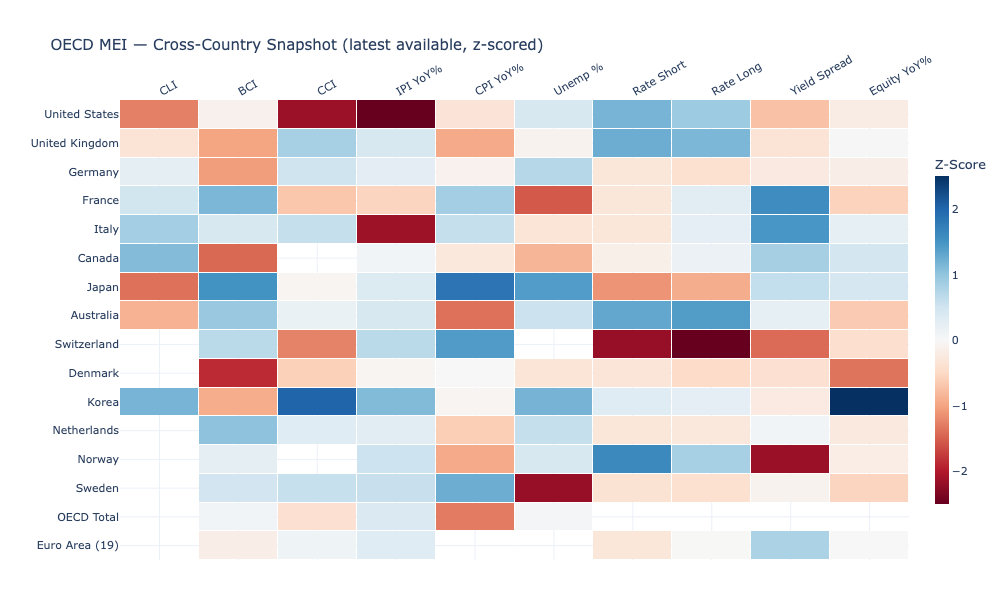

✅ F2 · Heatmap rendered


In [17]:
# ── F2 · Chart — Summary Heatmap ──────────────────────────────────────────────
_indicators = list(z_df.columns)
_countries  = [COUNTRY_LABELS.get(c, c) for c in z_df.index[::-1]]
_z          = z_df.iloc[::-1].values.tolist()
_raw        = raw_df.iloc[::-1].round(2).values.tolist()

heatmap_fig = go.Figure(go.Heatmap(
    z=_z, x=_indicators, y=_countries,
    colorscale="RdBu", zmid=0, zmin=-2.5, zmax=2.5,
    customdata=_raw,
    hovertemplate="<b>%{y}</b><br>%{x}: %{customdata} (z=%{z:.2f})<extra></extra>",
    colorbar=dict(title="Z-Score", thickness=14, len=0.8),
    xgap=1, ygap=1,
))
heatmap_fig.update_layout(
    title="OECD MEI — Cross-Country Snapshot (latest available, z-scored)",
    height=600, template="plotly_white",
    xaxis=dict(side="top", tickangle=-30),
    margin=dict(l=120, r=80, t=100, b=40), font=dict(size=11))

heatmap_fig.show()
print("✅ F2 · Heatmap rendered")


---
## Block G · Interactive Dashboard

In [20]:
# ── G1 · Define Interactive Widgets ──────────────────────────────────────────
fw_leading    = go.FigureWidget(leading_fig)
fw_production = go.FigureWidget(production_fig)
fw_labour     = go.FigureWidget(labour_fig)
fw_financial  = go.FigureWidget(financial_fig)
fw_heatmap    = go.FigureWidget(heatmap_fig)

_all_labels     = sorted([COUNTRY_LABELS.get(c, c) for c in COUNTRY_LIST])
_default_labels = [COUNTRY_LABELS.get(c, c) for c in G7 + AGGREGATES
                   if COUNTRY_LABELS.get(c, c) in _all_labels]

country_select = widgets.SelectMultiple(
    options=_all_labels,
    value=[v for v in _default_labels if v in _all_labels],
    rows=14, description="Countries",
    layout=widgets.Layout(width="200px"),
    style={"description_width": "70px"},
)

_all_dates = sorted(set(
    list(cli_wide.index) + list(ipi_wide.index)
    + list(unemp_wide.index) + list(rate_short_wide.index)
))
_date_opts = sorted(set(d.strftime("%Y-%m") for d in _all_dates if not pd.isnull(d)))

date_range = widgets.SelectionRangeSlider(
    options=_date_opts, index=(0, len(_date_opts)-1),
    description="Date range", continuous_update=False,
    layout=widgets.Layout(width="450px"),
    style={"description_width": "80px"},
)

smoothing_toggle = widgets.Checkbox(
    value=True, description="3M smoothing (CLI/BCI/CCI)", indent=False,
    layout=widgets.Layout(width="230px"),
)

category_tabs = widgets.Tab(children=[
    fw_leading, fw_production, fw_labour, fw_financial, fw_heatmap])
for i, t in enumerate(["Leading", "Production", "Labour", "Financial", "Heatmap"]):
    category_tabs.set_title(i, t)

print("✅ G1 · Widgets created")


✅ G1 · Widgets created


In [21]:
# ── G2 · Wire Callbacks & Display ────────────────────────────────────────────
_label_to_code = {v: k for k, v in COUNTRY_LABELS.items()}

def _selected_codes():
    return [_label_to_code.get(lbl, lbl) for lbl in country_select.value]

def _date_filter(s, d0, d1):
    try:
        return s.loc[d0:d1]
    except Exception:
        return s

def _update_fig(fw, traces_info):
    """traces_info: list of (trace, country_code, wide_df) tuples."""
    selected = set(_selected_codes())
    with fw.batch_update():
        for trace in fw.data:
            code = _label_to_code.get(trace.name, trace.name.split(" ")[0])
            visible = any(COUNTRY_LABELS.get(c, c) in trace.name for c in selected)
            trace.visible = True if visible else "legendonly"

def update_leading(change=None):
    use_smooth = smoothing_toggle.value
    d0, d1     = date_range.value
    src = {"CLI": cli_smooth if use_smooth else cli_wide,
           "BCI": bci_smooth if use_smooth else bci_wide,
           "CCI": cci_smooth if use_smooth else cci_wide}
    selected = set(_selected_codes())
    with fw_leading.batch_update():
        for trace in fw_leading.data:
            visible = any(COUNTRY_LABELS.get(c, c) == trace.name for c in selected)
            trace.visible = True if visible else "legendonly"

def update_production(change=None):
    _update_fig(fw_production, [])

def update_labour(change=None):
    selected = set(_selected_codes())
    d0, d1   = date_range.value
    with fw_labour.batch_update():
        for trace in fw_labour.data:
            visible = any(COUNTRY_LABELS.get(c, c) == trace.name for c in selected)
            trace.visible = True if visible else "legendonly"

def update_financial(change=None):
    _update_fig(fw_financial, [])

country_select.observe(
    lambda c: (update_leading(), update_production(), update_labour(), update_financial()),
    names="value")
date_range.observe(lambda c: update_leading(), names="value")
smoothing_toggle.observe(update_leading, names="value")

controls = widgets.VBox([
    widgets.HTML("<b>Filter Controls</b><hr style='margin:4px 0'>"),
    country_select,
    widgets.HTML("<br>"),
    date_range,
    widgets.HTML("<br>"),
    smoothing_toggle,
    widgets.HTML(
        f"<br><small style='color:#666'>OECD SDMX API<br>"
        f"Cache: {CACHE_DIR}<br>"
        f"Loaded: {datetime.now().strftime('%Y-%m-%d %H:%M')}</small>"),
], layout=widgets.Layout(width="250px", padding="8px",
                          border="1px solid #ddd"))

dashboard = widgets.HBox([controls, category_tabs],
                          layout=widgets.Layout(width="100%"))

print("✅ G2 · Dashboard ready — displaying ↓")
display(dashboard)


✅ G2 · Dashboard ready — displaying ↓
